# EDA trực quan hóa dữ liệu mưa

In [68]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.8),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

RAIN_THRESHOLD = 1.0
RAIN_COLOR = "#2C7FB8"
DRY_COLOR = "#FDB863"
ACCENT_COLOR = "#41AB5D"

DATA_PATH = Path("../data/features/feature_engineered_data.csv")
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy feature_engineered_data.csv. Hãy sửa DATA_PATH cho đúng vị trí file dữ liệu.")

STATION_NAME = {
    "48825099999": "Hà Đông",
    "48845099999": "Vinh",
    "48863099999": "Quảng Ngãi",
    "48877099999": "Nha Trang",
    "48914099999": "Cà Mau",
}

MONTH_LABELS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def clean_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, fontweight="bold", pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    sns.despine(ax=ax)
    return ax

def pct_axis(ax):
    ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    return ax

## 1. Load dữ liệu

In [69]:
df = pd.read_csv(DATA_PATH)

# Chuẩn hóa lại cột
df["STATION"] = df["STATION"].astype(str)
df["station_name"] = df["STATION"].map(STATION_NAME).fillna(df["STATION"])
df["time"] = pd.to_datetime(df["time"], errors="coerce", dayfirst=True)
df["PRCP"] = pd.to_numeric(df["PRCP"], errors="coerce")

# Giữ dữ liệu có target hợp lệ để trực quan hóa EDA
df = df.dropna(subset=["time", "PRCP", "PRCP_label"]).copy()
df = df[df["PRCP"] >= 0].copy()

df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["month_name"] = pd.Categorical(
    df["month"].map(lambda m: MONTH_LABELS[m - 1]),
    categories=MONTH_LABELS,
    ordered=True,
)

# Biến phụ để vẽ tỷ lệ mưa/không mưa
df["rain_status"] = np.where(df["PRCP_label"].eq(1), "Có mưa", "Không mưa")

# Biến log để trực quan hóa phân phối lệch phải của PRCP
if "PRCP_log1p" not in df.columns:
    df["PRCP_log1p"] = np.log1p(df["PRCP"])

train_df = df[df["year"] <= 2022].copy()
valid_df = df[df["year"] == 2023].copy()
test_df = df[df["year"] == 2024].copy()

non_feature_cols = {
    "STATION", "station_name", "time", "date", "DATE",
    "year", "month", "month_name", "rain_status",
    "PRCP", "PRCP_label", "PRCP_log1p",
    "target_1stage_prcp_mm",
    "target_stage1_rain_label",
    "target_stage2_prcp_log1p",
    "is_labeled", "PRCP_is_missing",
}

feature_cols = [
    c for c in train_df.select_dtypes(include="number").columns
    if c not in non_feature_cols and train_df[c].nunique(dropna=True) > 1
]

station_order = (
    df.groupby("station_name")["LATITUDE"]
    .mean()
    .sort_values(ascending=False)
    .index
)

summary = pd.DataFrame({
    "item": ["rows", "features", "stations", "date_min", "date_max", "rain_rate"],
    "value": [
        len(df),
        len(feature_cols),
        df["station_name"].nunique(),
        df["time"].min().date(),
        df["time"].max().date(),
        f"{df['PRCP_label'].mean():.2%}",
    ],
})

display(summary)

,item,value
0,rows,18026
1,features,70
2,stations,5
3,date_min,2015-01-01
4,date_max,2024-12-31
5,rain_rate,31.35%


## 2. Phân phối lượng mưa

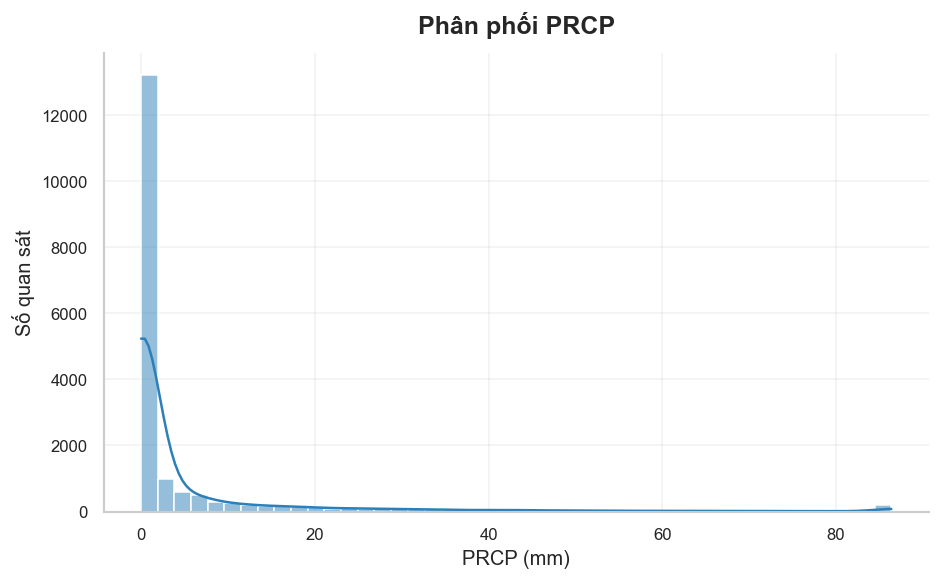

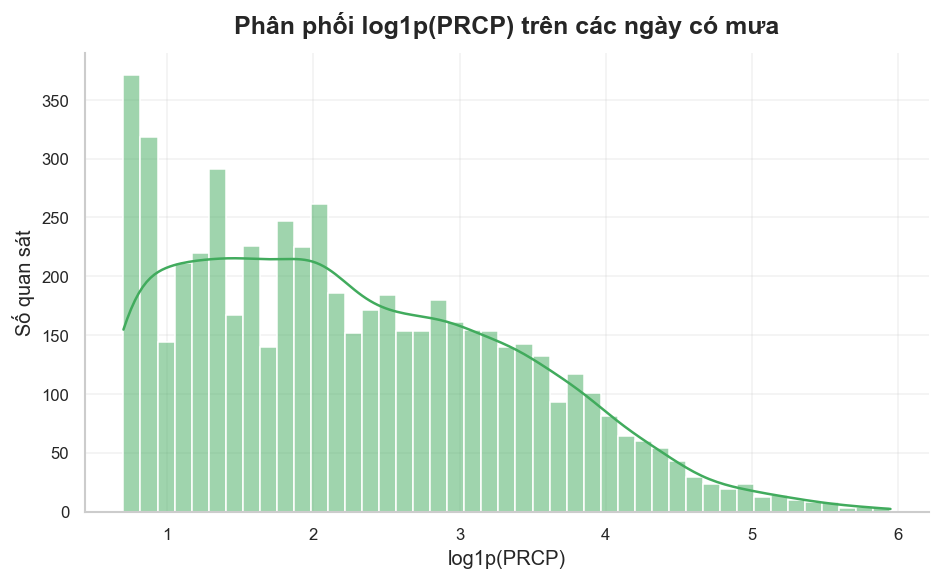

In [70]:
# Biểu đồ 1: Phân phối PRCP sau khi giới hạn percentile 99
cap = df["PRCP"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(df["PRCP"].clip(upper=cap), bins=45, kde=True, color=RAIN_COLOR)
clean_axis(
    plt.gca(),
    f"Phân phối PRCP",
    "PRCP (mm)",
    "Số quan sát",
)
plt.tight_layout()
plt.show()

# Biểu đồ 2: Phân phối log1p(PRCP) trên các ngày có mưa
plt.figure(figsize=(8, 5))
sns.histplot(df.loc[df["PRCP_label"].eq(1), "PRCP_log1p"], bins=45, kde=True, color=ACCENT_COLOR)
clean_axis(
    plt.gca(),
    "Phân phối log1p(PRCP) trên các ngày có mưa",
    "log1p(PRCP)",
    "Số quan sát",
)
plt.tight_layout()
plt.show()


## 3. Tỷ lệ mưa

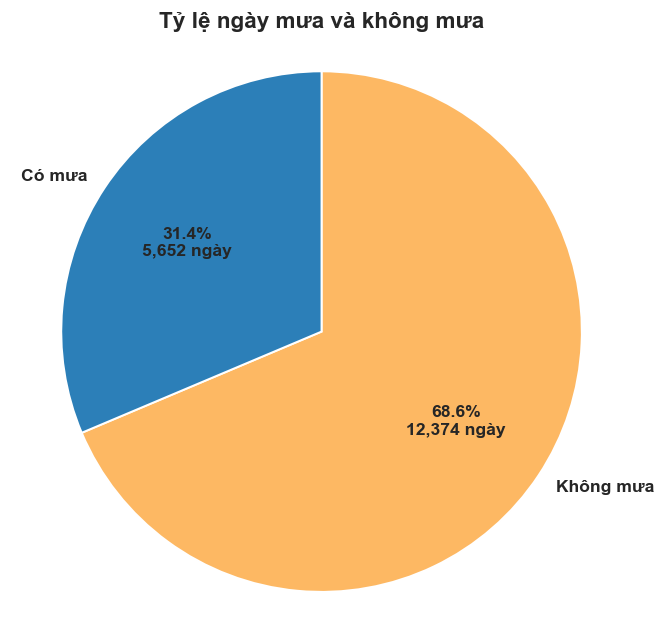

In [71]:
# =========================
# Biểu đồ 1: Tỷ lệ ngày mưa và không mưa
# =========================
rain_counts = (
    df["rain_status"]
    .value_counts()
    .reindex(["Không mưa", "Có mưa"])
    .fillna(0)
)

rain_colors = [DRY_COLOR, RAIN_COLOR]
rain_total = rain_counts.sum()

def show_pct_count(pct, total):
    count = int(round(pct * total / 100))
    return f"{pct:.1f}%\n{count:,} ngày"

plt.figure(figsize=(5.8, 5.4))

plt.pie(
    rain_counts.values,
    labels=rain_counts.index,
    colors=rain_colors,
    autopct=lambda pct: show_pct_count(pct, rain_total),
    startangle=90,
    counterclock=False,
    pctdistance=0.62,
    labeldistance=1.08,
    radius=0.88,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1.2
    },
    textprops={
        "fontsize": 10.5,
        "fontweight": "bold"
    }
)

plt.title(
    "Tỷ lệ ngày mưa và không mưa",
    fontsize=13.5,
    fontweight="bold",
    pad=12
)

plt.axis("equal")
plt.tight_layout()
plt.show()

## 4. Mùa vụ theo tháng

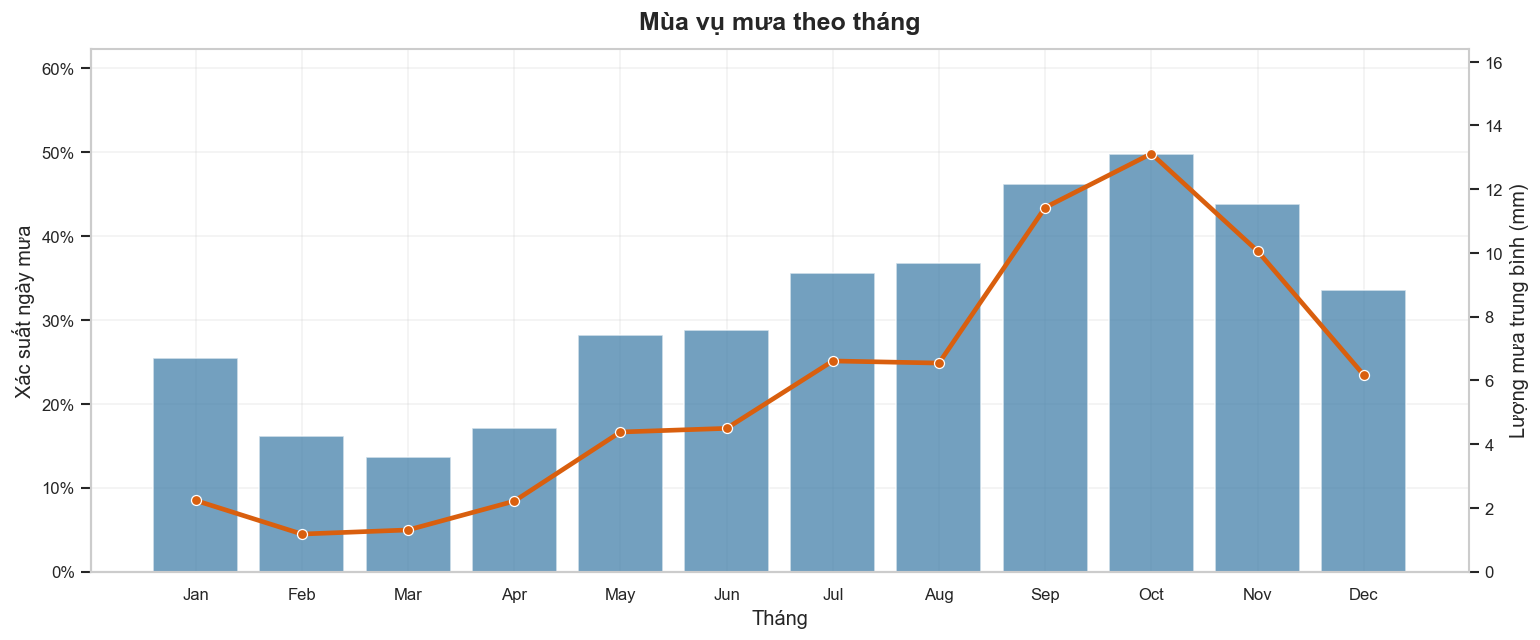

In [72]:
monthly = df.groupby("month", as_index=False).agg(
    rain_prob=("PRCP_label", "mean"),
    mean_prcp=("PRCP", "mean"),
    median_prcp=("PRCP", "median"),
)
monthly["month_name"] = pd.Categorical(monthly["month"].map(lambda m: MONTH_LABELS[m - 1]), MONTH_LABELS, ordered=True)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax2 = ax1.twinx()

sns.barplot(data=monthly, x="month_name", y="rain_prob", color=RAIN_COLOR, alpha=0.72, ax=ax1)
sns.lineplot(data=monthly, x="month_name", y="mean_prcp", color="#D95F0E", marker="o", linewidth=2.8, ax=ax2)

pct_axis(ax1)
ax1.set_ylim(0, max(monthly["rain_prob"].max() * 1.25, 0.1))
ax2.set_ylim(0, monthly["mean_prcp"].max() * 1.25)
clean_axis(ax1, "Mùa vụ mưa theo tháng", "Tháng", "Xác suất ngày mưa")
ax2.set_ylabel("Lượng mưa trung bình (mm)")
ax2.grid(False)

plt.tight_layout()
plt.show()

## 5. Heatmap mùa vụ và phân phối mưa theo trạm

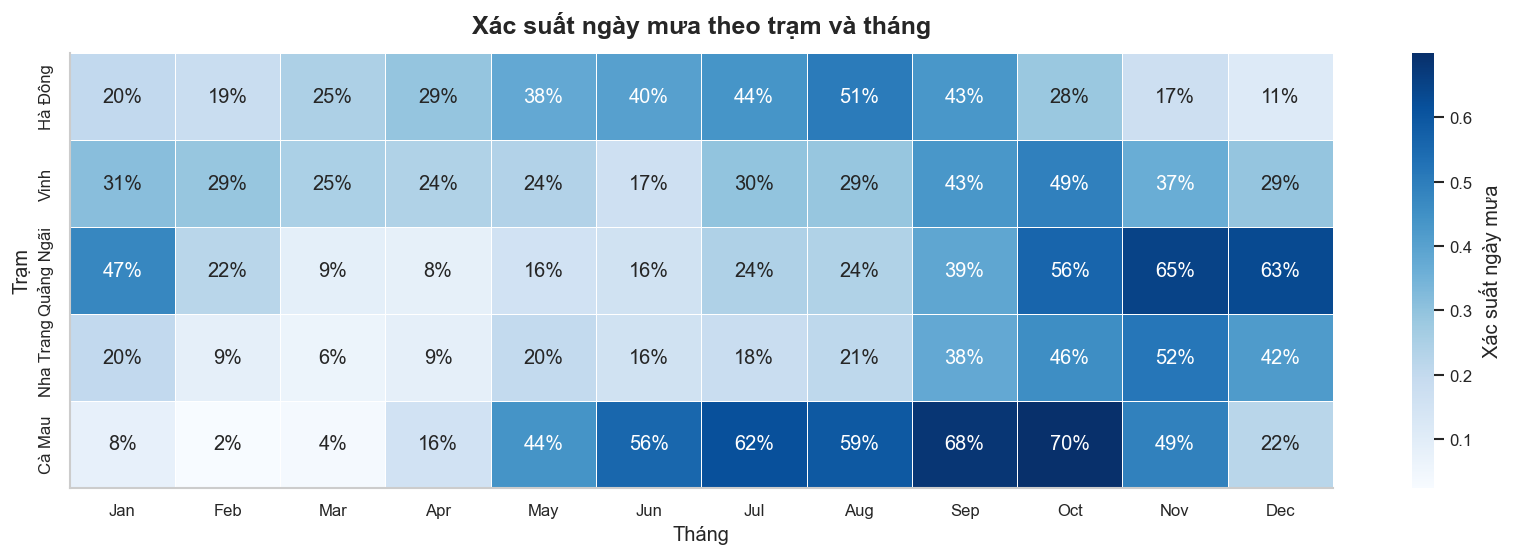

In [73]:
station_month = (
    df.pivot_table(index="station_name", columns="month_name", values="PRCP_label", aggfunc="mean")
    .reindex(station_order)
)

plt.figure(figsize=(14, 4.8))
ax = sns.heatmap(
    station_month,
    cmap="Blues",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    cbar_kws={"label": "Xác suất ngày mưa"},
)
clean_axis(ax, "Xác suất ngày mưa theo trạm và tháng", "Tháng", "Trạm")
plt.tight_layout()
plt.show()


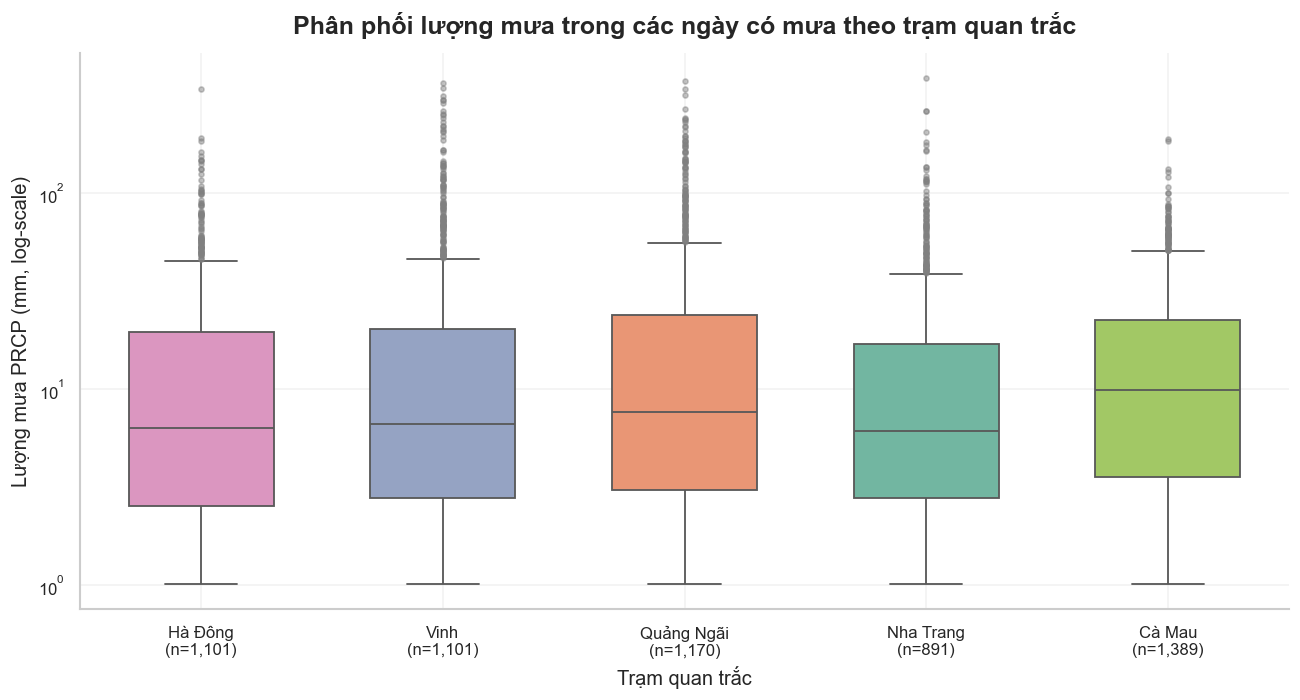

In [74]:
# Phân phối lượng mưa theo trạm trong các ngày có mưa
rainy_days = df[df["PRCP_label"].eq(1)].copy()

station_labels = (
    rainy_days["station_name"]
    .value_counts()
    .reindex(station_order)
    .dropna()
)

station_order_rainy = station_labels.index.tolist()
xtick_labels = [f"{station}\n(n={int(station_labels[station]):,})" for station in station_order_rainy]

plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    data=rainy_days,
    x="station_name",
    y="PRCP",
    order=station_order_rainy,
    hue="station_name",
    palette="Set2",
    showfliers=True,
    width=0.6,
    linewidth=1.1,
    legend=False,
    flierprops={
        "marker": "o",
        "markersize": 3,
        "markerfacecolor": "gray",
        "markeredgecolor": "gray",
        "alpha": 0.45,
    },
)

ax.set_yscale("log")
ax.set_xticklabels(xtick_labels)

clean_axis(
    ax,
    "Phân phối lượng mưa trong các ngày có mưa theo trạm quan trắc",
    "Trạm quan trắc",
    "Lượng mưa PRCP (mm, log-scale)"
)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Đa cộng tuyến giữa các feature quan trọng

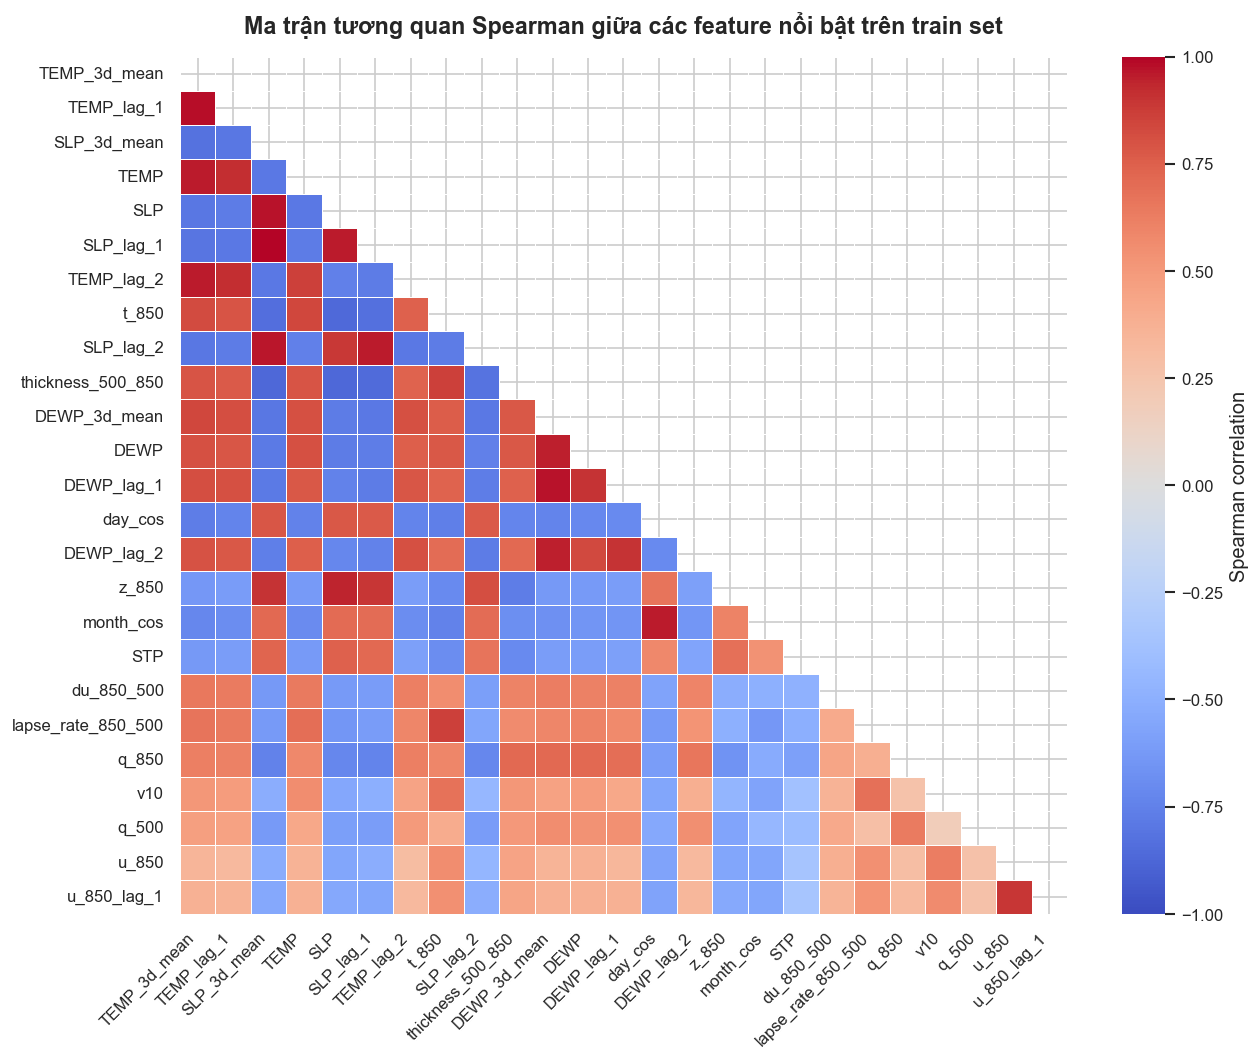

In [75]:
# Đa cộng tuyến giữa các feature trên train set
feature_corr = train_df[feature_cols].corr(method="spearman", numeric_only=True)

# Chọn các feature có mức liên hệ cao với nhiều feature khác để heatmap dễ đọc
top_corr_features = (
    feature_corr.abs()
    .mean()
    .sort_values(ascending=False)
    .head(25)
    .index
)

plt.figure(figsize=(11, 9))

mask = np.triu(np.ones_like(feature_corr.loc[top_corr_features, top_corr_features], dtype=bool))

ax = sns.heatmap(
    feature_corr.loc[top_corr_features, top_corr_features],
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    cbar_kws={"label": "Spearman correlation"}
)

plt.title(
    "Ma trận tương quan Spearman giữa các feature nổi bật trên train set",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Tương quan feature-target trên train set

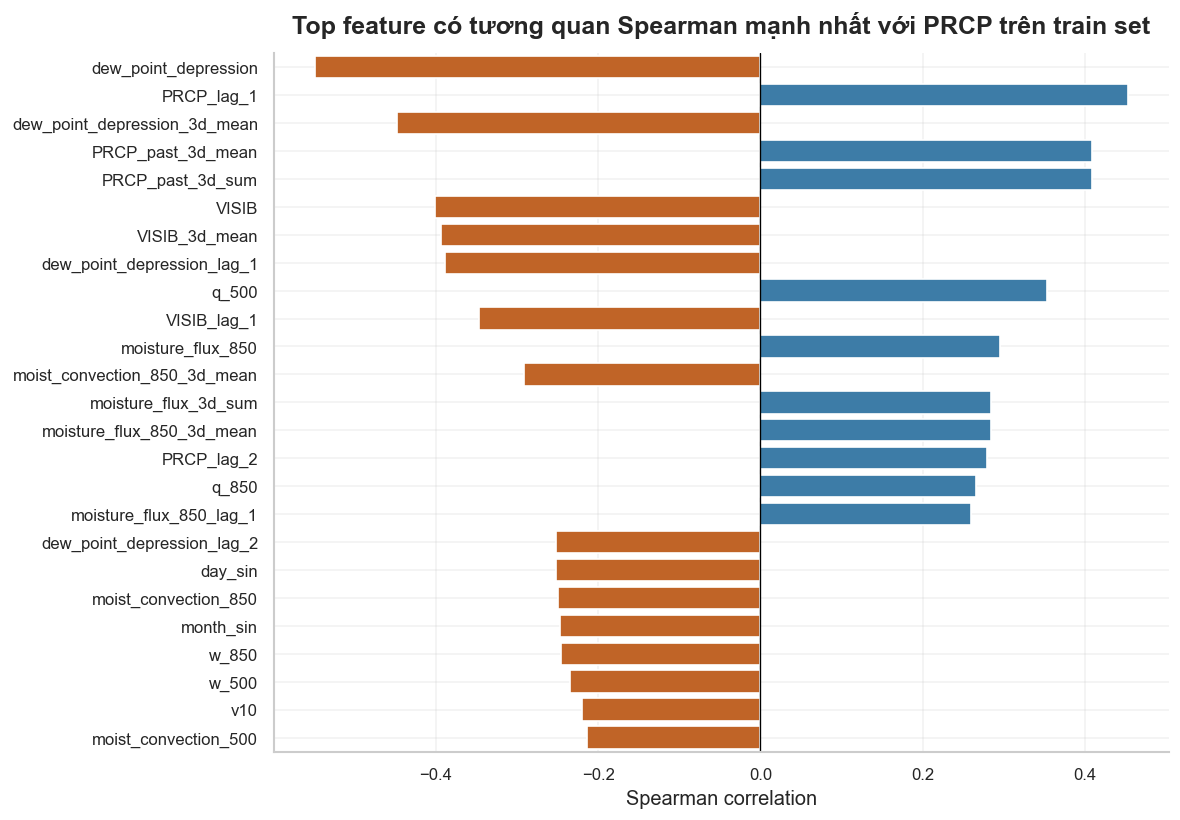

In [76]:
# Top feature có tương quan mạnh nhất với PRCP trên train set
target_corr = (
    train_df[feature_cols + ["PRCP"]]
    .corr(method="spearman", numeric_only=True)["PRCP"]
    .drop("PRCP")
    .dropna()
)

corr_df = (
    target_corr
    .reindex(target_corr.abs().sort_values(ascending=False).head(25).index)
    .reset_index()
)

corr_df.columns = ["feature", "spearman"]

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=corr_df,
    x="spearman",
    y="feature",
    hue=corr_df["spearman"] > 0,
    palette={True: RAIN_COLOR, False: "#D95F0E"},
    dodge=False,
    legend=False
)

ax.axvline(0, color="black", linewidth=0.8)

clean_axis(
    ax,
    "Top feature có tương quan Spearman mạnh nhất với PRCP trên train set",
    "Spearman correlation",
    ""
)

plt.tight_layout()
plt.show()

## 8. So sánh feature khí tượng giữa ngày mưa và không mưa

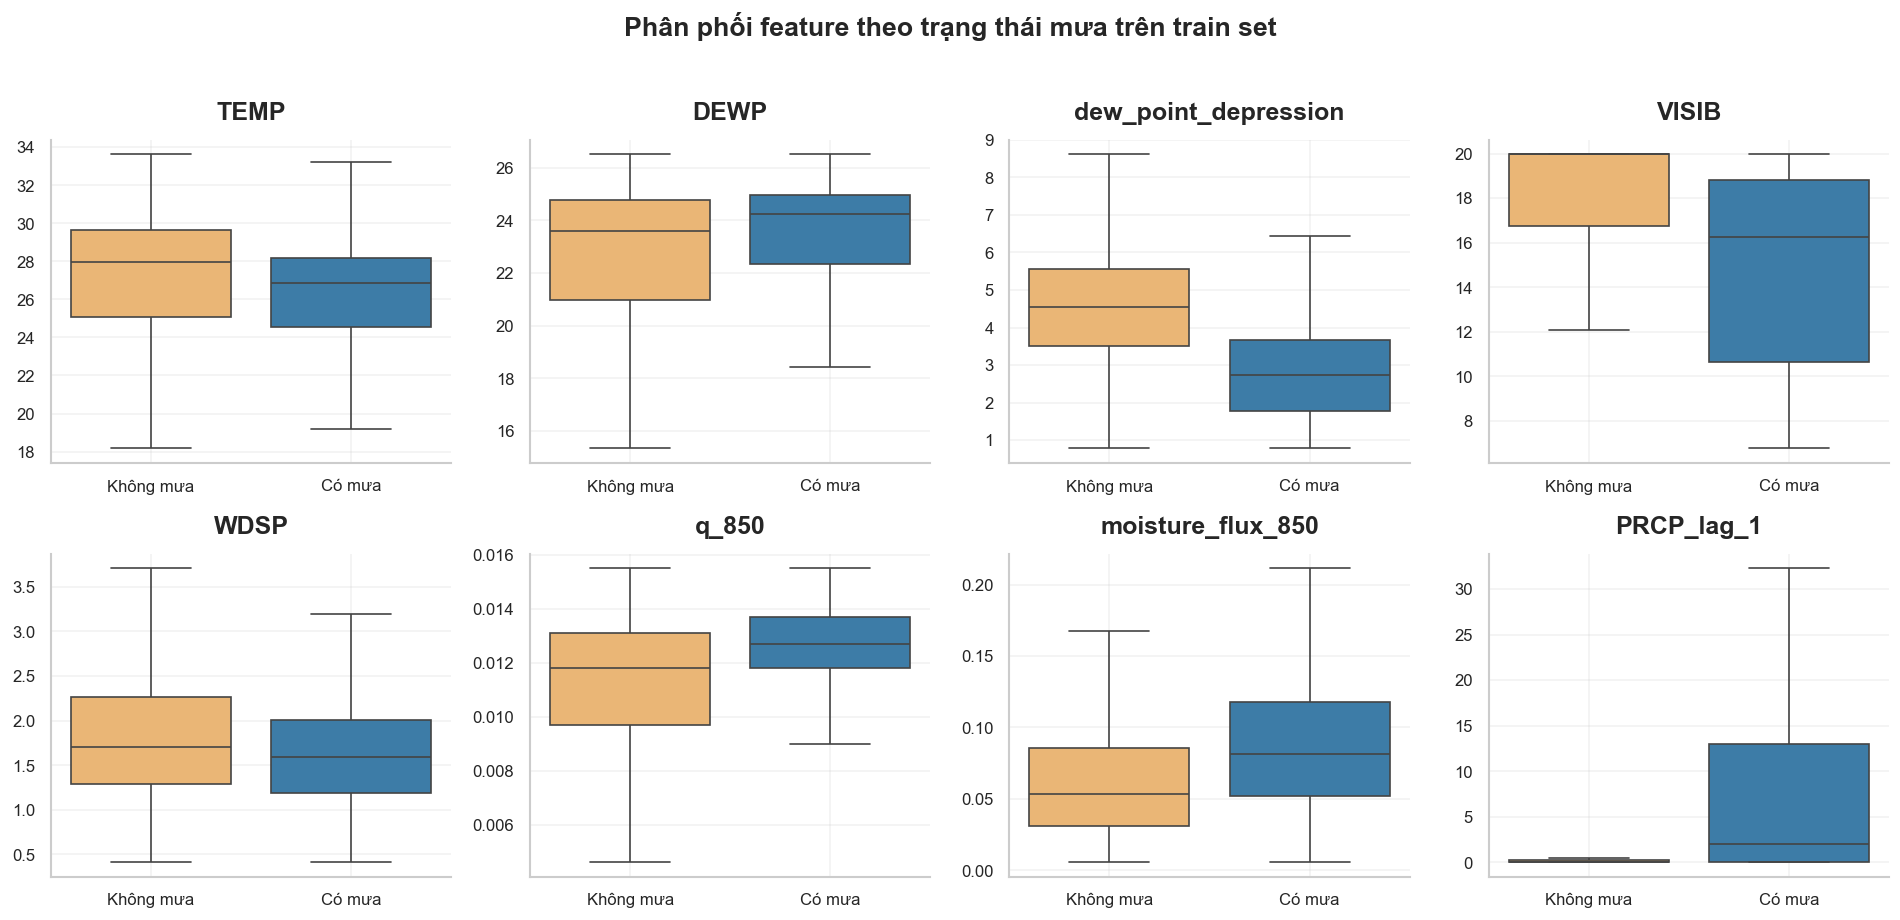

In [77]:
focus_features = [
    "TEMP", "DEWP", "dew_point_depression", "VISIB",
    "WDSP", "q_850", "moisture_flux_850", "PRCP_lag_1",
]
focus_features = [c for c in focus_features if c in train_df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
axes = axes.ravel()

for i, col in enumerate(focus_features):
    plot_df = train_df[["rain_status", col]].dropna().copy()
    low, high = plot_df[col].quantile([0.01, 0.99])
    plot_df[col] = plot_df[col].clip(low, high)
    sns.boxplot(
        data=plot_df,
        x="rain_status",
        y=col,
        order=["Không mưa", "Có mưa"],
        palette={"Không mưa": DRY_COLOR, "Có mưa": RAIN_COLOR},
        showfliers=False,
        ax=axes[i],
    )
    clean_axis(axes[i], col, "", "")

for j in range(len(focus_features), len(axes)):
    axes[j].axis("off")

fig.suptitle("Phân phối feature theo trạng thái mưa trên train set", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 9. Redundancy pairs để chuẩn bị chọn lọc đặc trưng

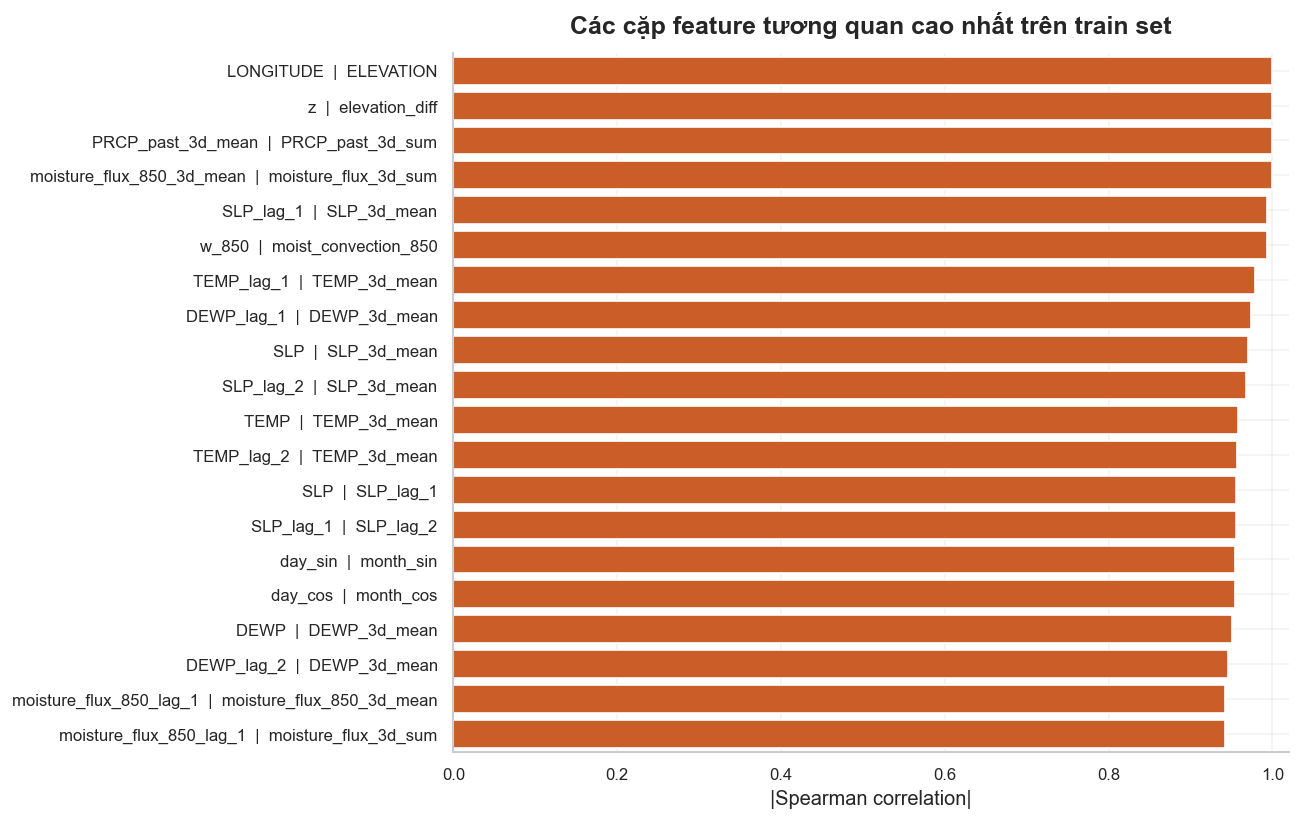

,feature_1,feature_2,abs_corr,pair
0,LONGITUDE,ELEVATION,1.000000,LONGITUDE | ELEVATION
1,z,elevation_diff,1.000000,z | elevation_diff
2,PRCP_past_3d_mean,PRCP_past_3d_sum,0.999989,PRCP_past_3d_mean | PRCP_past_3d_sum
3,moisture_flux_850_3d_mean,moisture_flux_3d_sum,0.999617,moisture_flux_850_3d_mean | moisture_flux_3d...
4,SLP_lag_1,SLP_3d_mean,0.993020,SLP_lag_1 | SLP_3d_mean
5,w_850,moist_convection_850,0.992896,w_850 | moist_convection_850
6,TEMP_lag_1,TEMP_3d_mean,0.979028,TEMP_lag_1 | TEMP_3d_mean
7,DEWP_lag_1,DEWP_3d_mean,0.974070,DEWP_lag_1 | DEWP_3d_mean
8,SLP,SLP_3d_mean,0.969833,SLP | SLP_3d_mean
9,SLP_lag_2,SLP_3d_mean,0.967836,SLP_lag_2 | SLP_3d_mean


In [78]:
redundancy = train_df[feature_cols].corr(method="spearman", numeric_only=True).abs()
upper = redundancy.where(np.triu(np.ones(redundancy.shape), k=1).astype(bool))

pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "abs_corr"]
pairs["pair"] = pairs["feature_1"] + "  |  " + pairs["feature_2"]

plt.figure(figsize=(11, 7))
ax = sns.barplot(data=pairs, x="abs_corr", y="pair", color="#E6550D")
ax.set_xlim(0, 1.02)
clean_axis(ax, "Các cặp feature tương quan cao nhất trên train set", "|Spearman correlation|", "")
plt.tight_layout()
plt.show()

display(pairs.head(10))
